ESCENARIO 03 CLAUDE.IA - CON REGLAS, VERSIÓN GRATIS

REPORTE DE AVANCE FÍSICO Y CONTROL DE OBRA

Avance físico consolidado: 61.14 %

Avance por disciplina:
  - Civil: 87.39 %
  - Eléctrica: 51.46 %
  - Instrumentación: 31.42 %
  - Mecánica estática: 69.27 %
  - Rotativa: 26.21 %

Indicadores de Valor Ganado (EVM):
  PV (Valor Planificado) : 39,520,591.76 USD
  EV (Valor Ganado)      : 33,947,130.85 USD
  AC (Costo Real)        : 35,031,285.00 USD
  SPI (Índice de Cronograma): 0.859
  CPI (Índice de Costo)     : 0.969

Interpretación:
  - SPI = 0.859 < 1 → la obra está ATRASADA respecto al cronograma.
  - CPI = 0.969 < 1 → la obra presenta SOBRECOSTO respecto a lo planificado.

INCONSISTENCIAS DETECTADAS: 6
  [Actividad STAP-ELE-019] id_actividad duplicado
  [Actividad STAP-CIV-005] cantidad_ejecutada (67) mayor que cantidad_planificada (63)
  [Actividad STAP-MEC-012] cantidad_ejecutada (814) mayor que cantidad_planificada (775)
  [Actividad STAP-ELE-007] cantidad_ejecutada (10614) mayor que cantidad_planificada (10108)
  [Actividad STAP-

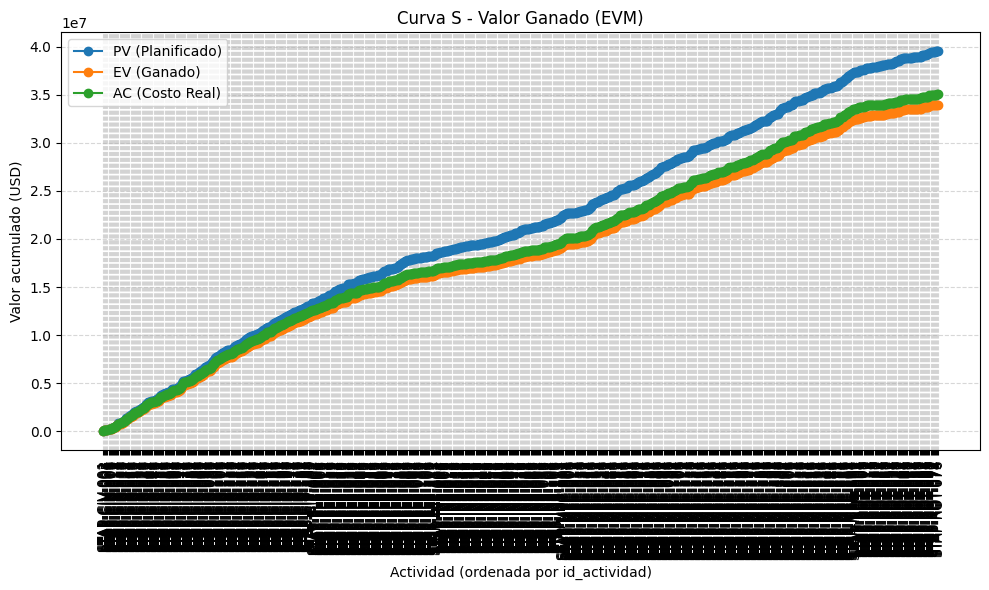

In [1]:
# =============================================================================
# CONTROL DE AVANCE FÍSICO Y VALOR GANADO (EVM) - OBRA DE CONSTRUCCIÓN
# Ejecutar directamente en una celda de Google Colab.
# Requiere el archivo "02_Dataset_Base_STAP.csv" en la misma carpeta.
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 0. CONFIGURACIÓN Y CONSTANTES
# -----------------------------------------------------------------------------
NOMBRE_ARCHIVO = "02_Dataset_Base_STAP.csv"

UNIDADES_VALIDAS = {"pulg_diam", "kg", "m", "m2", "m3", "und"}
DISCIPLINAS_VALIDAS = {"Civil", "Mecánica estática", "Rotativa", "Instrumentación", "Eléctrica"}

COLUMNAS_REQUERIDAS = [
    "id_actividad", "disciplina", "descripcion", "unidad",
    "cantidad_planificada", "cantidad_ejecutada", "peso_presupuesto_usd",
    "avance_planificado_pct", "costo_real_usd"
]

inconsistencias = []  # lista de tuplas (id_actividad, descripcion_problema)


def registrar_inconsistencia(id_act, mensaje):
    inconsistencias.append((id_act, mensaje))


# -----------------------------------------------------------------------------
# 1. LECTURA DEL ARCHIVO
# -----------------------------------------------------------------------------
try:
    df = pd.read_csv(NOMBRE_ARCHIVO, sep=",", encoding="utf-8")
except FileNotFoundError:
    raise SystemExit(
        f"ERROR: No se encontró el archivo '{NOMBRE_ARCHIVO}' en la carpeta actual. "
        f"Verifique que esté cargado en el entorno de Colab."
    )

# Verificación mínima de columnas requeridas
faltantes = [c for c in COLUMNAS_REQUERIDAS if c not in df.columns]
if faltantes:
    raise SystemExit(f"ERROR: Faltan columnas obligatorias en el CSV: {faltantes}")

# Aseguramos tipos numéricos (valores no convertibles quedan como NaN)
columnas_numericas = [
    "cantidad_planificada", "cantidad_ejecutada", "peso_presupuesto_usd",
    "avance_planificado_pct", "costo_real_usd"
]
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# id_actividad como texto para evitar problemas de comparación
df["id_actividad"] = df["id_actividad"].astype(str)


# -----------------------------------------------------------------------------
# 2. VALIDACIONES (se reportan, no detienen el programa)
# -----------------------------------------------------------------------------

# 2.1 id_actividad duplicado
duplicados_mask = df["id_actividad"].duplicated(keep=False)
for id_act in df.loc[duplicados_mask, "id_actividad"].unique():
    registrar_inconsistencia(id_act, "id_actividad duplicado")

# 2.2 cantidad_ejecutada mayor que la planificada
for _, fila in df.iterrows():
    cp, ce = fila["cantidad_planificada"], fila["cantidad_ejecutada"]
    if pd.notna(cp) and pd.notna(ce) and ce > cp:
        registrar_inconsistencia(
            fila["id_actividad"],
            f"cantidad_ejecutada ({ce}) mayor que cantidad_planificada ({cp})"
        )

# 2.3 peso_presupuesto_usd nulo, negativo o ausente
for _, fila in df.iterrows():
    peso = fila["peso_presupuesto_usd"]
    if pd.isna(peso):
        registrar_inconsistencia(fila["id_actividad"], "peso_presupuesto_usd ausente o nulo")
    elif peso < 0:
        registrar_inconsistencia(fila["id_actividad"], f"peso_presupuesto_usd negativo ({peso})")

# 2.4 unidad no reconocida
for _, fila in df.iterrows():
    unidad = fila["unidad"]
    if pd.isna(unidad) or str(unidad).strip() not in UNIDADES_VALIDAS:
        registrar_inconsistencia(fila["id_actividad"], f"unidad no reconocida ('{unidad}')")

# 2.5 disciplina no reconocida
for _, fila in df.iterrows():
    disciplina = fila["disciplina"]
    if pd.isna(disciplina) or str(disciplina).strip() not in DISCIPLINAS_VALIDAS:
        registrar_inconsistencia(fila["id_actividad"], f"disciplina no reconocida ('{disciplina}')")

# 2.6 avance_planificado_pct fuera de [0, 1]
for _, fila in df.iterrows():
    avp = fila["avance_planificado_pct"]
    if pd.isna(avp) or avp < 0 or avp > 1:
        registrar_inconsistencia(fila["id_actividad"], f"avance_planificado_pct fuera de rango ({avp})")

# 2.7 (robustez adicional, no rompe el programa) cantidad_planificada nula o cero
for _, fila in df.iterrows():
    cp = fila["cantidad_planificada"]
    if pd.isna(cp) or cp == 0:
        registrar_inconsistencia(fila["id_actividad"], "cantidad_planificada nula o igual a cero")


# -----------------------------------------------------------------------------
# 3. CÁLCULO DE AVANCE POR ACTIVIDAD
# -----------------------------------------------------------------------------
def calcular_avance(fila):
    cp = fila["cantidad_planificada"]
    ce = fila["cantidad_ejecutada"]
    if pd.isna(cp) or cp == 0 or pd.isna(ce):
        return 0.0
    avance = ce / cp
    return min(max(avance, 0.0), 1.0)  # acotado a [0, 1]


df["avance_actividad"] = df.apply(calcular_avance, axis=1)

# Peso efectivo: si el peso es nulo/negativo/ausente, se usa 0 para no distorsionar
# los cálculos consolidados (la inconsistencia ya fue reportada en la sección 2).
df["peso_efectivo"] = df["peso_presupuesto_usd"].apply(
    lambda p: p if (pd.notna(p) and p >= 0) else 0.0
)

# avance_planificado_pct efectivo (si está fuera de rango o nulo, se acota a 0 para
# los cálculos de PV; la inconsistencia ya quedó reportada).
df["avance_plan_efectivo"] = df["avance_planificado_pct"].apply(
    lambda x: min(max(x, 0.0), 1.0) if pd.notna(x) else 0.0
)

# costo_real_usd efectivo (NaN se trata como 0 para no romper la sumatoria de AC)
df["costo_real_efectivo"] = df["costo_real_usd"].fillna(0.0)


# -----------------------------------------------------------------------------
# 4. AVANCE FÍSICO CONSOLIDADO Y POR DISCIPLINA
# -----------------------------------------------------------------------------
suma_pesos = df["peso_efectivo"].sum()

if suma_pesos > 0:
    avance_fisico_consolidado = (df["avance_actividad"] * df["peso_efectivo"]).sum() / suma_pesos
else:
    avance_fisico_consolidado = float("nan")

avance_por_disciplina = {}
for disciplina, grupo in df.groupby("disciplina"):
    peso_grupo = grupo["peso_efectivo"].sum()
    if peso_grupo > 0:
        avance_disc = (grupo["avance_actividad"] * grupo["peso_efectivo"]).sum() / peso_grupo
    else:
        avance_disc = float("nan")
    avance_por_disciplina[disciplina] = avance_disc


# -----------------------------------------------------------------------------
# 5. VALOR GANADO (EVM)
# -----------------------------------------------------------------------------
PV = (df["peso_efectivo"] * df["avance_plan_efectivo"]).sum()
EV = (df["peso_efectivo"] * df["avance_actividad"]).sum()
AC = df["costo_real_efectivo"].sum()

SPI = EV / PV if PV != 0 else float("nan")
CPI = EV / AC if AC != 0 else float("nan")


def interpretar_spi(spi):
    if pd.isna(spi):
        return "No calculable (PV = 0)."
    if spi > 1:
        return f"SPI = {spi:.3f} > 1 → la obra está ADELANTADA respecto al cronograma."
    elif spi < 1:
        return f"SPI = {spi:.3f} < 1 → la obra está ATRASADA respecto al cronograma."
    else:
        return f"SPI = {spi:.3f} = 1 → la obra está EXACTAMENTE a tiempo."


def interpretar_cpi(cpi):
    if pd.isna(cpi):
        return "No calculable (AC = 0)."
    if cpi > 1:
        return f"CPI = {cpi:.3f} > 1 → la obra presenta AHORRO respecto al costo real."
    elif cpi < 1:
        return f"CPI = {cpi:.3f} < 1 → la obra presenta SOBRECOSTO respecto a lo planificado."
    else:
        return f"CPI = {cpi:.3f} = 1 → el costo real coincide con el valor ganado."


# -----------------------------------------------------------------------------
# 6. SALIDA POR PANTALLA
# -----------------------------------------------------------------------------
print("=" * 70)
print("REPORTE DE AVANCE FÍSICO Y CONTROL DE OBRA")
print("=" * 70)

print(f"\nAvance físico consolidado: {avance_fisico_consolidado * 100:.2f} %")

print("\nAvance por disciplina:")
for disciplina, avance in avance_por_disciplina.items():
    if pd.isna(avance):
        print(f"  - {disciplina}: No calculable (peso total = 0)")
    else:
        print(f"  - {disciplina}: {avance * 100:.2f} %")

print("\nIndicadores de Valor Ganado (EVM):")
print(f"  PV (Valor Planificado) : {PV:,.2f} USD")
print(f"  EV (Valor Ganado)      : {EV:,.2f} USD")
print(f"  AC (Costo Real)        : {AC:,.2f} USD")
print(f"  SPI (Índice de Cronograma): {SPI:.3f}" if pd.notna(SPI) else "  SPI: No calculable")
print(f"  CPI (Índice de Costo)     : {CPI:.3f}" if pd.notna(CPI) else "  CPI: No calculable")

print("\nInterpretación:")
print(f"  - {interpretar_spi(SPI)}")
print(f"  - {interpretar_cpi(CPI)}")

print("\n" + "=" * 70)
print(f"INCONSISTENCIAS DETECTADAS: {len(inconsistencias)}")
print("=" * 70)
if inconsistencias:
    for id_act, mensaje in inconsistencias:
        print(f"  [Actividad {id_act}] {mensaje}")
else:
    print("  No se detectaron inconsistencias.")


# -----------------------------------------------------------------------------
# 7. CURVA S (PV, EV, AC ACUMULADOS)
# -----------------------------------------------------------------------------
df_ordenado = df.sort_values("id_actividad").reset_index(drop=True)

df_ordenado["PV_actividad"] = df_ordenado["peso_efectivo"] * df_ordenado["avance_plan_efectivo"]
df_ordenado["EV_actividad"] = df_ordenado["peso_efectivo"] * df_ordenado["avance_actividad"]
df_ordenado["AC_actividad"] = df_ordenado["costo_real_efectivo"]

df_ordenado["PV_acum"] = df_ordenado["PV_actividad"].cumsum()
df_ordenado["EV_acum"] = df_ordenado["EV_actividad"].cumsum()
df_ordenado["AC_acum"] = df_ordenado["AC_actividad"].cumsum()

plt.figure(figsize=(10, 6))
plt.plot(df_ordenado["id_actividad"], df_ordenado["PV_acum"], marker="o", label="PV (Planificado)")
plt.plot(df_ordenado["id_actividad"], df_ordenado["EV_acum"], marker="o", label="EV (Ganado)")
plt.plot(df_ordenado["id_actividad"], df_ordenado["AC_acum"], marker="o", label="AC (Costo Real)")

plt.title("Curva S - Valor Ganado (EVM)")
plt.xlabel("Actividad (ordenada por id_actividad)")
plt.ylabel("Valor acumulado (USD)")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()